# PRT565 — Baseline Models
Project: **Explainable and Cost-Sensitive Phishing Website Detection Using Machine Learning and Deep Learning**

Trains Decision Tree, Random Forest, Gaussian Naive Bayes and Multilayer ANN. Dataset labels: **0=phishing, 1=legitimate**.

In [1]:
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
DATA_DIR=Path('.')
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay,classification_report
OUT=Path('results_baseline'); OUT.mkdir(exist_ok=True)

In [3]:
def xy(d): return d.drop(columns='label'),d['label']
train=pd.read_csv(DATA_DIR/'train.csv'); test=pd.read_csv(DATA_DIR/'test.csv')
train_s=pd.read_csv(DATA_DIR/'train_scaled.csv'); test_s=pd.read_csv(DATA_DIR/'test_scaled.csv')
Xtr,ytr=xy(train); Xte,yte=xy(test); Xtr_s,_=xy(train_s); Xte_s,_=xy(test_s)
print(train.shape,test.shape); print(ytr.value_counts().sort_index())

(164490, 51) (35249, 51)
label
0    70096
1    94394
Name: count, dtype: int64


In [4]:
models={
'Decision Tree':(DecisionTreeClassifier(random_state=42),Xtr,Xte),
'Random Forest':(RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1),Xtr,Xte),
'Gaussian Naive Bayes':(GaussianNB(),Xtr_s,Xte_s),
'Multilayer ANN':(MLPClassifier(hidden_layer_sizes=(128,64),max_iter=100,early_stopping=True,validation_fraction=.15,random_state=42),Xtr_s,Xte_s)}

Training Decision Tree
              precision    recall  f1-score   support

    Phishing     1.0000    1.0000    1.0000     15021
  Legitimate     1.0000    1.0000    1.0000     20228

    accuracy                         1.0000     35249
   macro avg     1.0000    1.0000    1.0000     35249
weighted avg     1.0000    1.0000    1.0000     35249



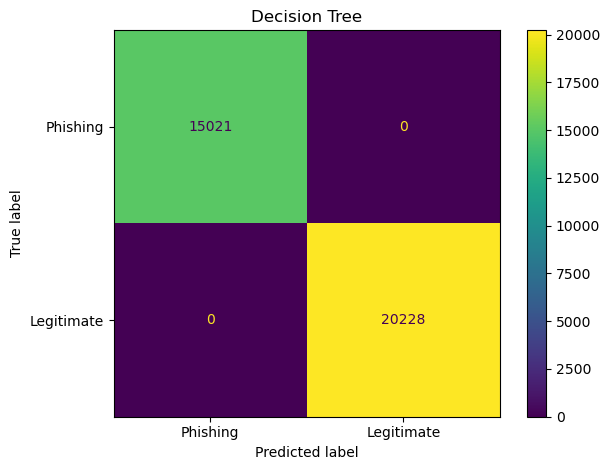

Training Random Forest
              precision    recall  f1-score   support

    Phishing     1.0000    1.0000    1.0000     15021
  Legitimate     1.0000    1.0000    1.0000     20228

    accuracy                         1.0000     35249
   macro avg     1.0000    1.0000    1.0000     35249
weighted avg     1.0000    1.0000    1.0000     35249



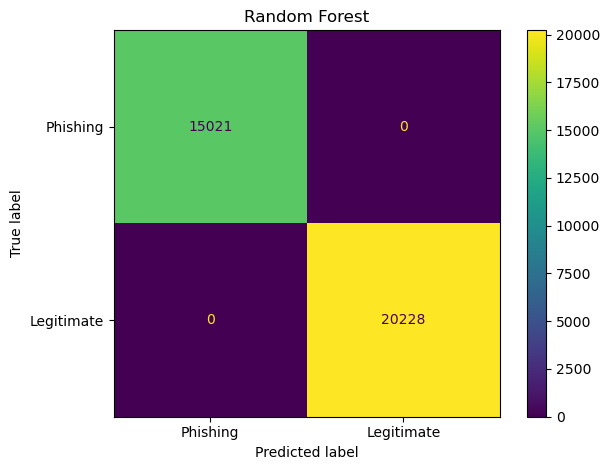

Training Gaussian Naive Bayes
              precision    recall  f1-score   support

    Phishing     0.9993    0.9998    0.9995     15021
  Legitimate     0.9999    0.9995    0.9997     20228

    accuracy                         0.9996     35249
   macro avg     0.9996    0.9996    0.9996     35249
weighted avg     0.9996    0.9996    0.9996     35249



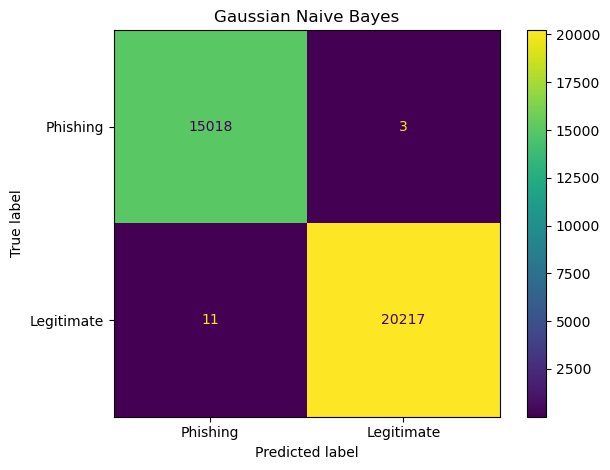

Training Multilayer ANN
              precision    recall  f1-score   support

    Phishing     0.9998    1.0000    0.9999     15021
  Legitimate     1.0000    0.9999    0.9999     20228

    accuracy                         0.9999     35249
   macro avg     0.9999    0.9999    0.9999     35249
weighted avg     0.9999    0.9999    0.9999     35249



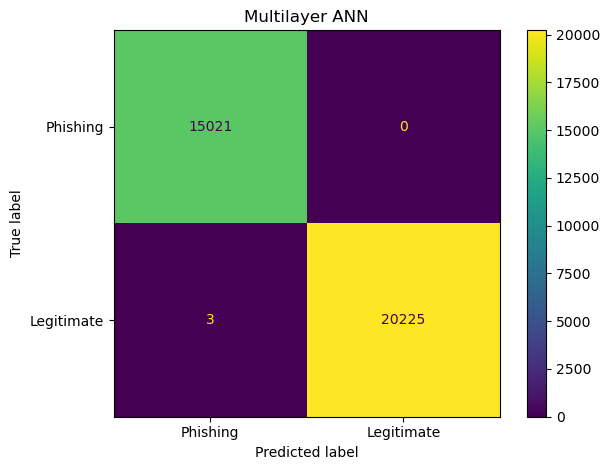

,Model,Accuracy,Phishing Precision,Phishing Recall,Phishing F1,ROC-AUC,Phishing Missed (FN),Legitimate Flagged (FP)
0,Decision Tree,1.0000,1.0000,1.0000,1.0000,1.0000,0,0
1,Random Forest,1.0000,1.0000,1.0000,1.0000,1.0000,0,0
3,Multilayer ANN,0.9999,0.9998,1.0000,0.9999,1.0000,0,3
2,Gaussian Naive Bayes,0.9996,0.9993,0.9998,0.9995,0.9999,3,11


In [5]:
rows=[]
for name,(m,a,b) in models.items():
 print('Training',name); m.fit(a,ytr); p=m.predict(b); prob=m.predict_proba(b)[:,1]; cm=confusion_matrix(yte,p,labels=[0,1])
 rows.append({'Model':name,'Accuracy':accuracy_score(yte,p),'Phishing Precision':precision_score(yte,p,pos_label=0),'Phishing Recall':recall_score(yte,p,pos_label=0),'Phishing F1':f1_score(yte,p,pos_label=0),'ROC-AUC':roc_auc_score(yte,prob),'Phishing Missed (FN)':int(cm[0,1]),'Legitimate Flagged (FP)':int(cm[1,0])})
 print(classification_report(yte,p,target_names=['Phishing','Legitimate'],digits=4))
 ConfusionMatrixDisplay(cm,display_labels=['Phishing','Legitimate']).plot(values_format='d'); plt.title(name); plt.tight_layout(); plt.savefig(OUT/f"{name.replace(' ','_')}_cm.png",dpi=200); plt.show()
res=pd.DataFrame(rows).sort_values('Phishing F1',ascending=False); display(res.round(4)); res.to_csv(OUT/'baseline_model_results.csv',index=False)

In [ ]:
ax=res.set_index('Model')[['Accuracy','Phishing Precision','Phishing Recall','Phishing F1']].plot(kind='bar',figsize=(10,6)); ax.set_ylim(0,1.05); plt.xticks(rotation=20,ha='right'); plt.tight_layout(); plt.savefig(OUT/'baseline_comparison.png',dpi=200); plt.show()